# HEART DISEASE DATASET - ADVANCED ANALYSIS & ML WITH UNIQUE VISUALIZATIONS

## Dataset: Heart Disease UCI
**Kaynak:** https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

## Proje Hedefi: KALP HASTALIGI TAHMINI (BINARY CLASSIFICATION)

## Ozellikler:
- Medical-focused EDA
- 15+ FARKLI GRAFIK TIPI (Violin, Pair, Joint, KDE, Radar, 3D, vb.)
- 13+ ML Model (Neural Network dahil)
- Ensemble Methods (Voting, Stacking)
- Advanced Feature Engineering
- Detailed Medical Insights

## Proje Asamalari:
1. Veri Yukleme (Wget)
2. Medical EDA - Unique Visualizations
3. Advanced Feature Engineering
4. 13+ Model Training
5. Ensemble Methods
6. Advanced Model Comparison
7. Medical Insights & Recommendations

## 1. KUTUPHANE YUKLEME

In [4]:
# Temel kutuphaneler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Veri islemleri
import os
import subprocess
import zipfile
import glob
from scipy import stats
from scipy.stats import chi2_contingency

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE

# ML Modelleri
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier,
    VotingClassifier, StackingClassifier, BaggingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# CatBoost yuklemesi (hata olmamasi icin)
!pip install catboost
from catboost import CatBoostClassifier

# Metrikler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, matthews_corrcoef
)

# Plotly for interactive plots
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True
except:
    PLOTLY_AVAILABLE = False
    print('Plotly yuklenemedi - interaktif grafikler devre disi')

# Gorsellestirme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
%matplotlib inline

# Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

print('='*70)
print('KUTUPHANELER YUKLENDI!')
print('='*70)
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')
print(f'Scikit-learn loaded')
print(f'Plotly: {"Available" if PLOTLY_AVAILABLE else "Not Available"}')
print('='*70)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.3 MB/s eta 0:00:00
KUTUPHANELER YUKLENDI!
NumPy: 2.0.2
Pandas: 2.2.2
Scikit-learn loaded
Plotly: Available


## 2. VERI YUKLEME

In [6]:
def download_dataset_direct(download_url, dest_folder, zip_filename):
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)

    full_zip_path = os.path.join(dest_folder, zip_filename)

    print(f"\n{'='*70}")
    print(f"Indiriliyor: {zip_filename}")
    print(f"URL: {download_url}")
    print(f"{'='*70}")

    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        print(f"\nIndirme basarili")
        return True
    except Exception as e:
        print(f"\nIndirme hatasi: {e}")
        return False

def extract_dataset(dest_folder):
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        if not zip_files:
            return False

        for zip_file in zip_files:
            print(f"\nAciliyor: {zip_file}")
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(dest_folder)
            os.remove(zip_file)

        print(f"\nDataset hazir: {dest_folder}")
        return True
    except Exception as e:
        print(f"Hata: {e}")
        return False

In [7]:
# Dataset
dataset_folder = "heart_disease_dataset"
os.makedirs(dataset_folder, exist_ok=True)

dataset_info = {
    "name": "heart-disease-dataset",
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/johnsmith88/heart-disease-dataset",
    "folder": dataset_folder,
    "zip_filename": "heart-disease.zip"
}

# CSV var mi kontrol
csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if csv_files:
    print("\n" + "="*70)
    print("Dataset zaten mevcut!")
    print("="*70)
else:
    print("\n" + "="*70)
    print("HEART DISEASE DATASET INDIRILIYOR")
    print("="*70)

    success = download_dataset_direct(
        dataset_info["download_url"],
        dataset_info["folder"],
        dataset_info["zip_filename"]
    )

    if success:
        extract_dataset(dataset_info["folder"])
    else:
        print("\nMANUEL INDIRME GEREKLI")
        print("1. https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset")
        print("2. Download")
        print(f"3. {dataset_folder}/")


HEART DISEASE DATASET INDIRILIYOR

Indiriliyor: heart-disease.zip
URL: https://www.kaggle.com/api/v1/datasets/download/johnsmith88/heart-disease-dataset

Indirme basarili

Aciliyor: heart_disease_dataset/heart-disease.zip

Dataset hazir: heart_disease_dataset


In [8]:
# CSV yukle
csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if csv_files:
    file_path = csv_files[0]
    print(f'Dosya: {os.path.basename(file_path)}')
    df = pd.read_csv(file_path)

    print('='*70)
    print('VERI YUKLENDI!')
    print('='*70)
    print(f'Kayit: {len(df):,}')
    print(f'Sutun: {len(df.columns)}')
    print(f'Bellek: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
    print('='*70)
else:
    print('CSV bulunamadi!')

Dosya: heart.csv
VERI YUKLENDI!
Kayit: 1,025
Sutun: 14
Bellek: 0.11 MB


In [9]:
# Sutun isimlerini standardize et
df.columns = df.columns.str.lower().str.strip()

# Ilk bakis
print('ILK 10 KAYIT:')
df.head(10)

ILK 10 KAYIT:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.000,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.100,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.600,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.000,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.900,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.000,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.400,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.800,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.800,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.200,1,2,2,0


In [10]:
# Veri yapisi
print('VERI YAPISI:')
df.info()

VERI YAPISI:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


## 3. MEDICAL EDA - UNIQUE VISUALIZATIONS

In [11]:
# Hedef degisken
target_col = 'target' if 'target' in df.columns else df.columns[-1]

print('='*70)
print(f'HEDEF DEGISKEN: {target_col}')
print('='*70)
print(df[target_col].value_counts())
print(f'\nDagilim:')
print(df[target_col].value_counts(normalize=True) * 100)

HEDEF DEGISKEN: target
target
1    526
0    499
Name: count, dtype: int64

Dagilim:
target
1   51.317
0   48.683
Name: proportion, dtype: float64


### GRAFIK 1: VIOLIN PLOTS (Age & Cholesterol by Target)

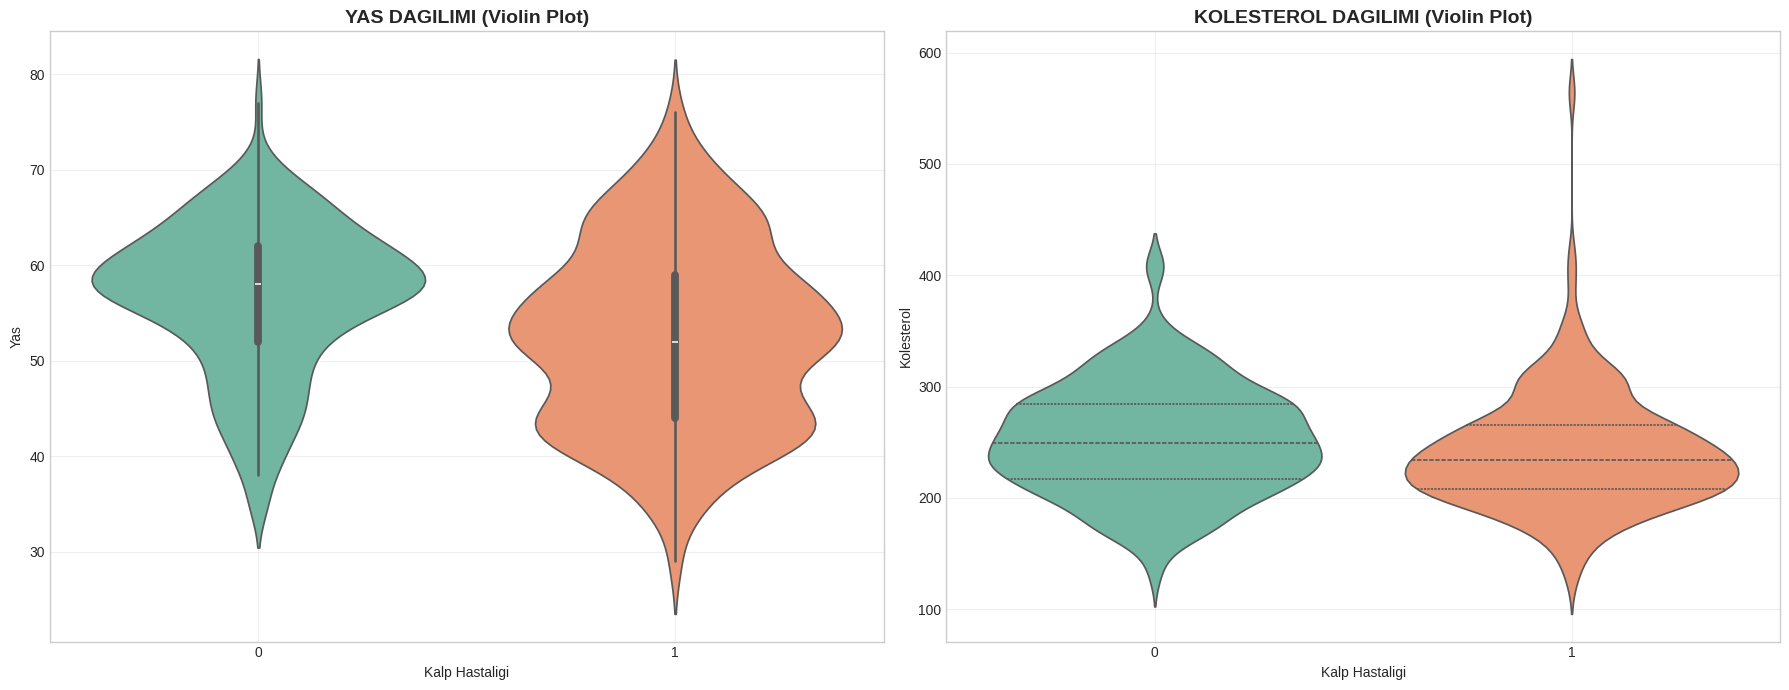

In [12]:
# Violin plots - Age ve Cholesterol
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Age violin
if 'age' in df.columns:
    sns.violinplot(data=df, x=target_col, y='age', ax=axes[0],
                  palette='Set2', inner='box')
    axes[0].set_title('YAS DAGILIMI (Violin Plot)', fontweight='bold', fontsize=14)
    axes[0].set_xlabel('Kalp Hastaligi')
    axes[0].set_ylabel('Yas')
    axes[0].grid(alpha=0.3)

# Cholesterol violin
chol_col = [col for col in df.columns if 'chol' in col.lower()]
if chol_col:
    sns.violinplot(data=df, x=target_col, y=chol_col[0], ax=axes[1],
                  palette='Set2', inner='quartile')
    axes[1].set_title('KOLESTEROL DAGILIMI (Violin Plot)', fontweight='bold', fontsize=14)
    axes[1].set_xlabel('Kalp Hastaligi')
    axes[1].set_ylabel('Kolesterol')
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### GRAFIK 2: PAIR PLOT (Multivariate Analysis)

PAIR PLOT olusturuluyor (bu biraz zaman alabilir)...


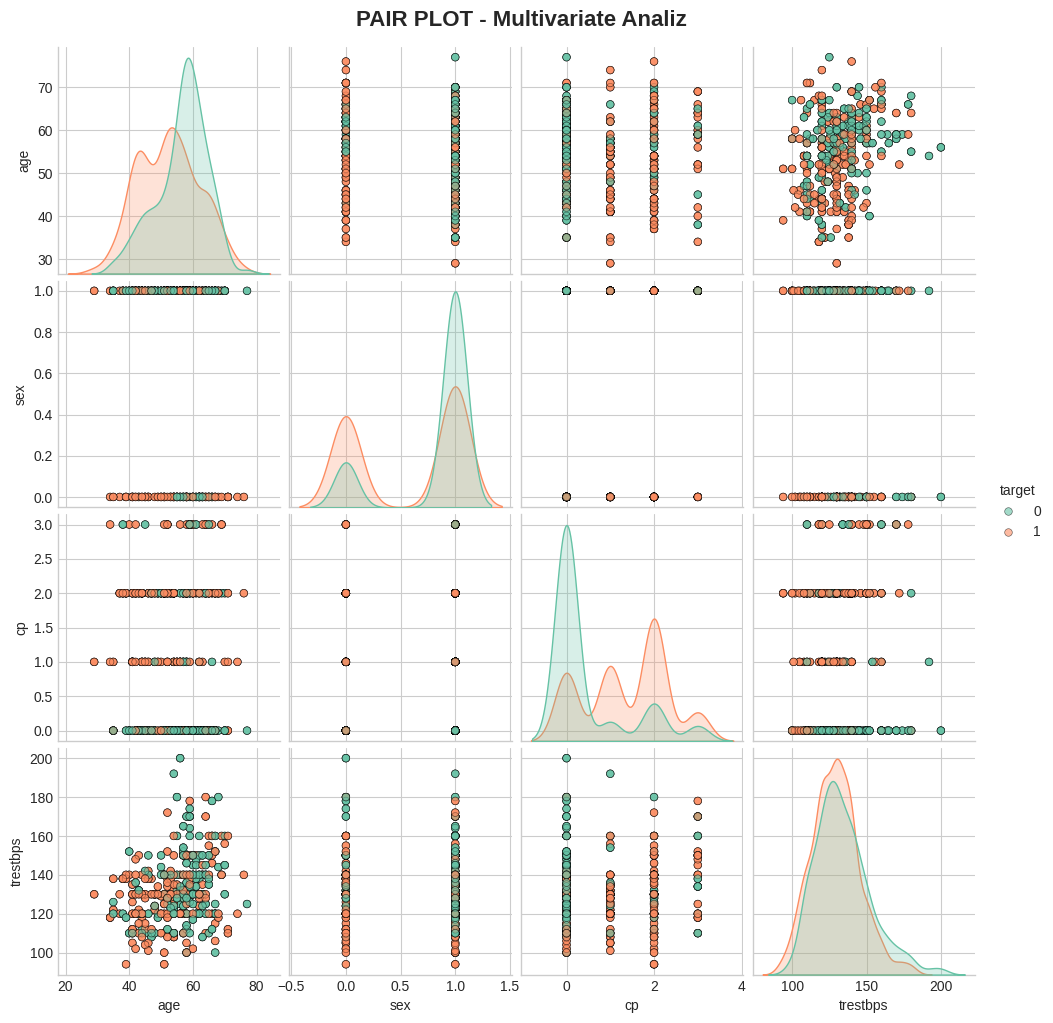

In [13]:
# Pair plot - Numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

# En onemli 4 numeric feature
important_cols = numeric_cols[:4] + [target_col]

print('PAIR PLOT olusturuluyor (bu biraz zaman alabilir)...')
pair_plot = sns.pairplot(df[important_cols], hue=target_col,
                        palette='Set2', diag_kind='kde',
                        plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k'})
pair_plot.fig.suptitle('PAIR PLOT - Multivariate Analiz', y=1.02, fontweight='bold', fontsize=16)
plt.show()

### GRAFIK 3: JOINT PLOT (Age vs Cholesterol)

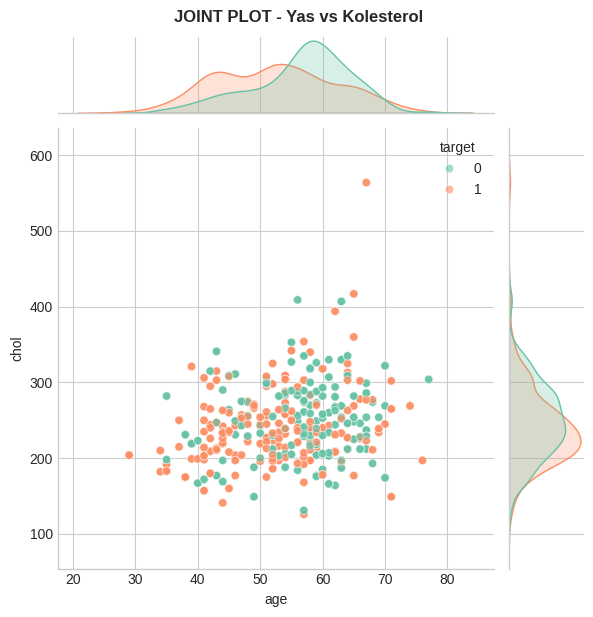

In [15]:
# Joint plot
if 'age' in df.columns and chol_col:
    joint = sns.jointplot(data=df, x='age', y=chol_col[0],
                         hue=target_col, kind='scatter',
                         palette='Set2', alpha=0.6,
                         marginal_kws={'fill': True})
    joint.fig.suptitle('JOINT PLOT - Yas vs Kolesterol', y=1.02, fontweight='bold')
    plt.show()

### GRAFIK 4: KDE PLOTS (Kernel Density)

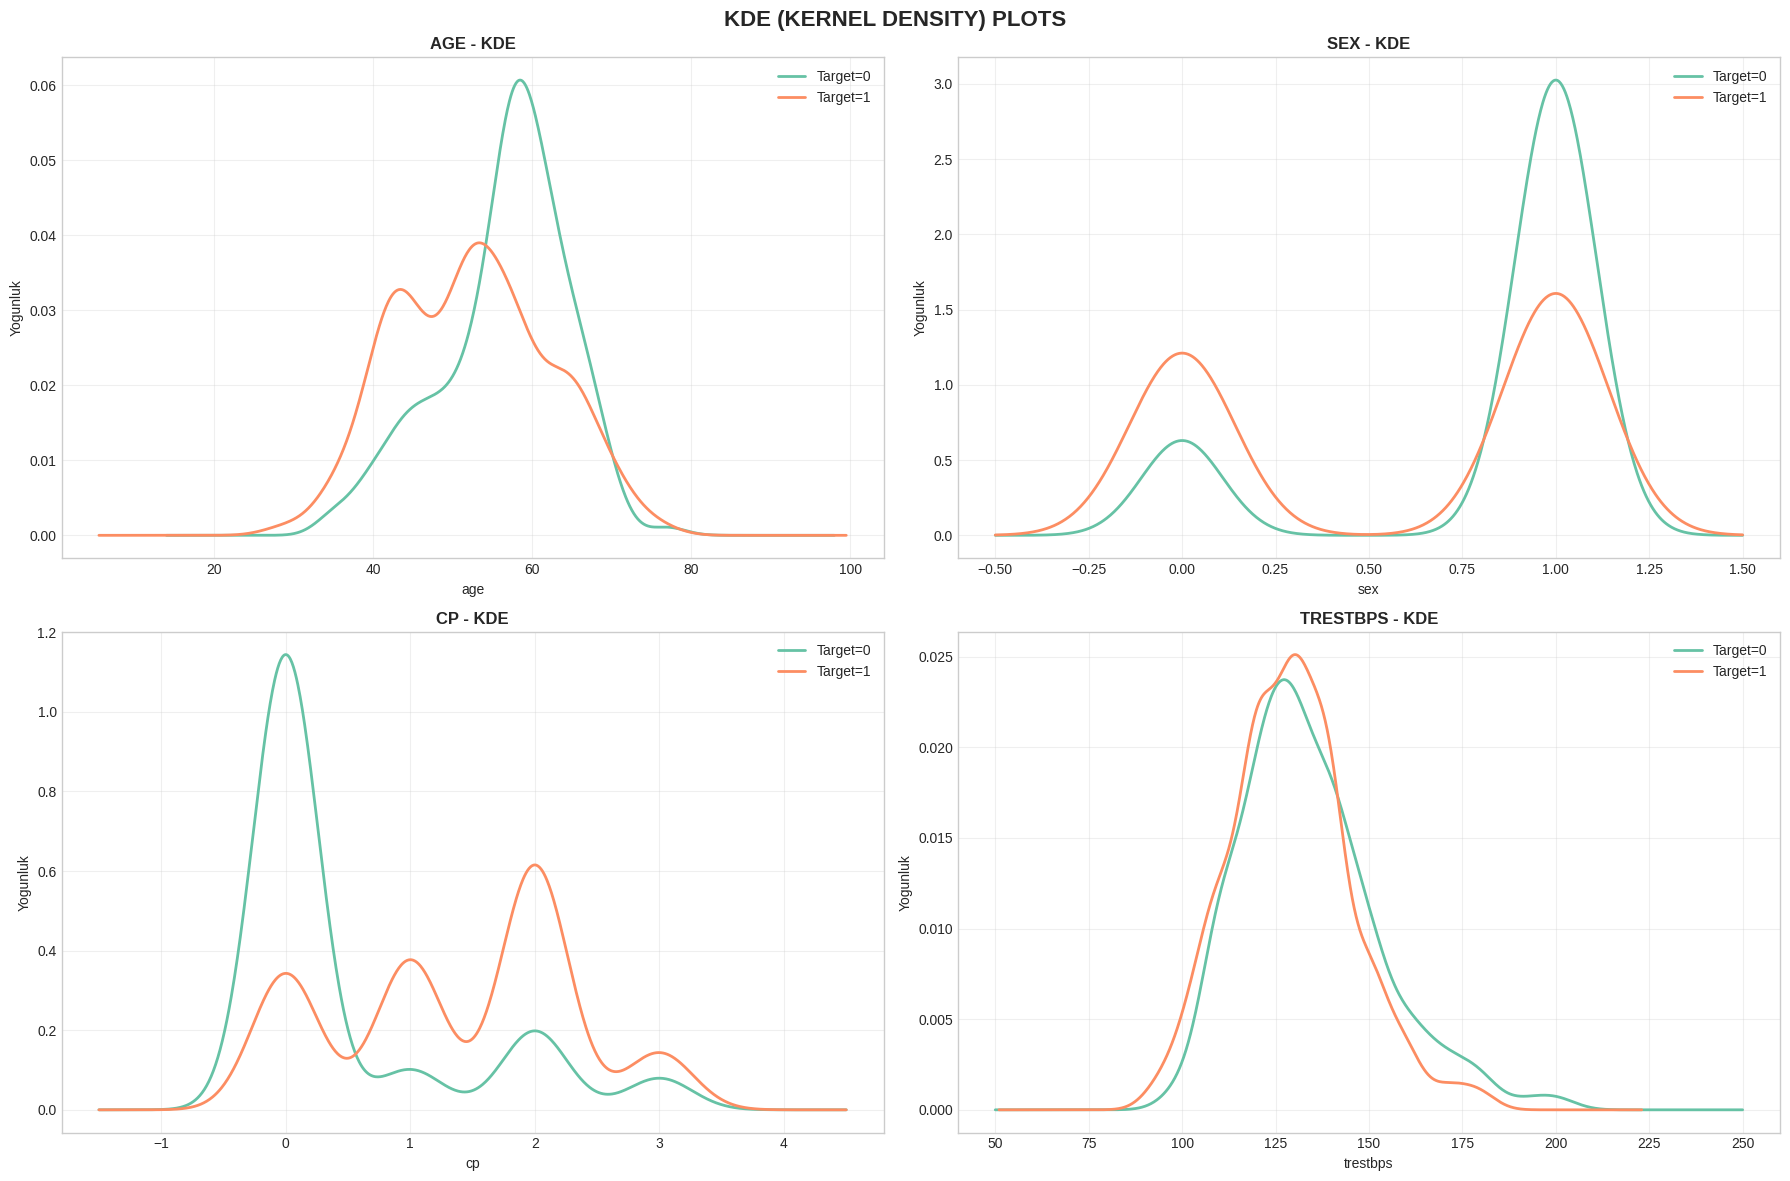

In [16]:
# KDE plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('KDE (KERNEL DENSITY) PLOTS', fontweight='bold', fontsize=16)

plot_features = numeric_cols[:4]

for idx, feature in enumerate(plot_features):
    ax = axes[idx // 2, idx % 2]

    for target_val in df[target_col].unique():
        subset = df[df[target_col] == target_val][feature].dropna()
        subset.plot.kde(ax=ax, label=f'Target={target_val}', linewidth=2)

    ax.set_title(f'{feature.upper()} - KDE', fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Yogunluk')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### GRAFIK 5: BOX-VIOLIN COMBINATION

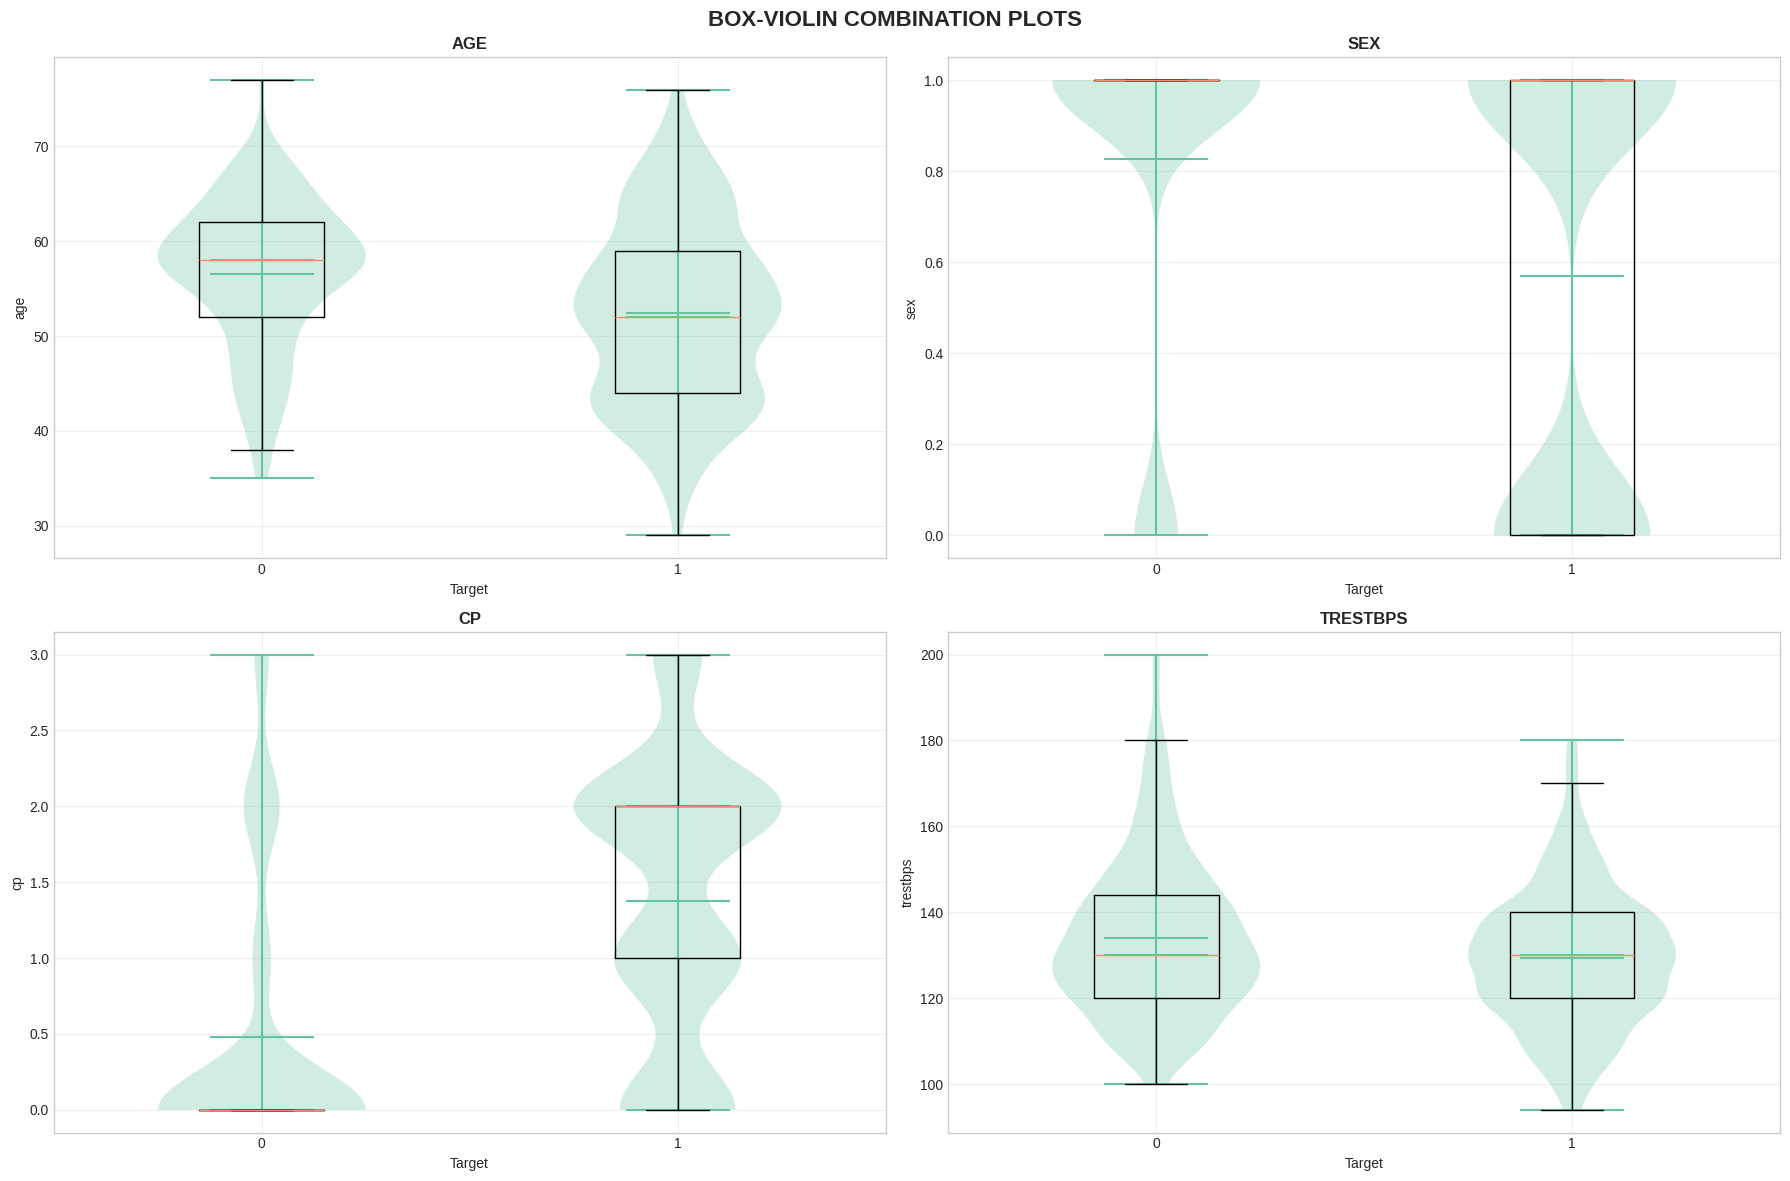

In [17]:
# Box-Violin combination
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('BOX-VIOLIN COMBINATION PLOTS', fontweight='bold', fontsize=16)

for idx, feature in enumerate(numeric_cols[:4]):
    ax = axes[idx // 2, idx % 2]

    # Violin
    parts = ax.violinplot([df[df[target_col] == t][feature].dropna()
                           for t in sorted(df[target_col].unique())],
                          positions=sorted(df[target_col].unique()),
                          showmeans=True, showmedians=True)

    # Box uzerine
    ax.boxplot([df[df[target_col] == t][feature].dropna()
                for t in sorted(df[target_col].unique())],
               positions=sorted(df[target_col].unique()),
               widths=0.3, showfliers=False)

    ax.set_title(f'{feature.upper()}', fontweight='bold')
    ax.set_xlabel('Target')
    ax.set_ylabel(feature)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### GRAFIK 6: SWARM PLOT (Categorical Analysis)

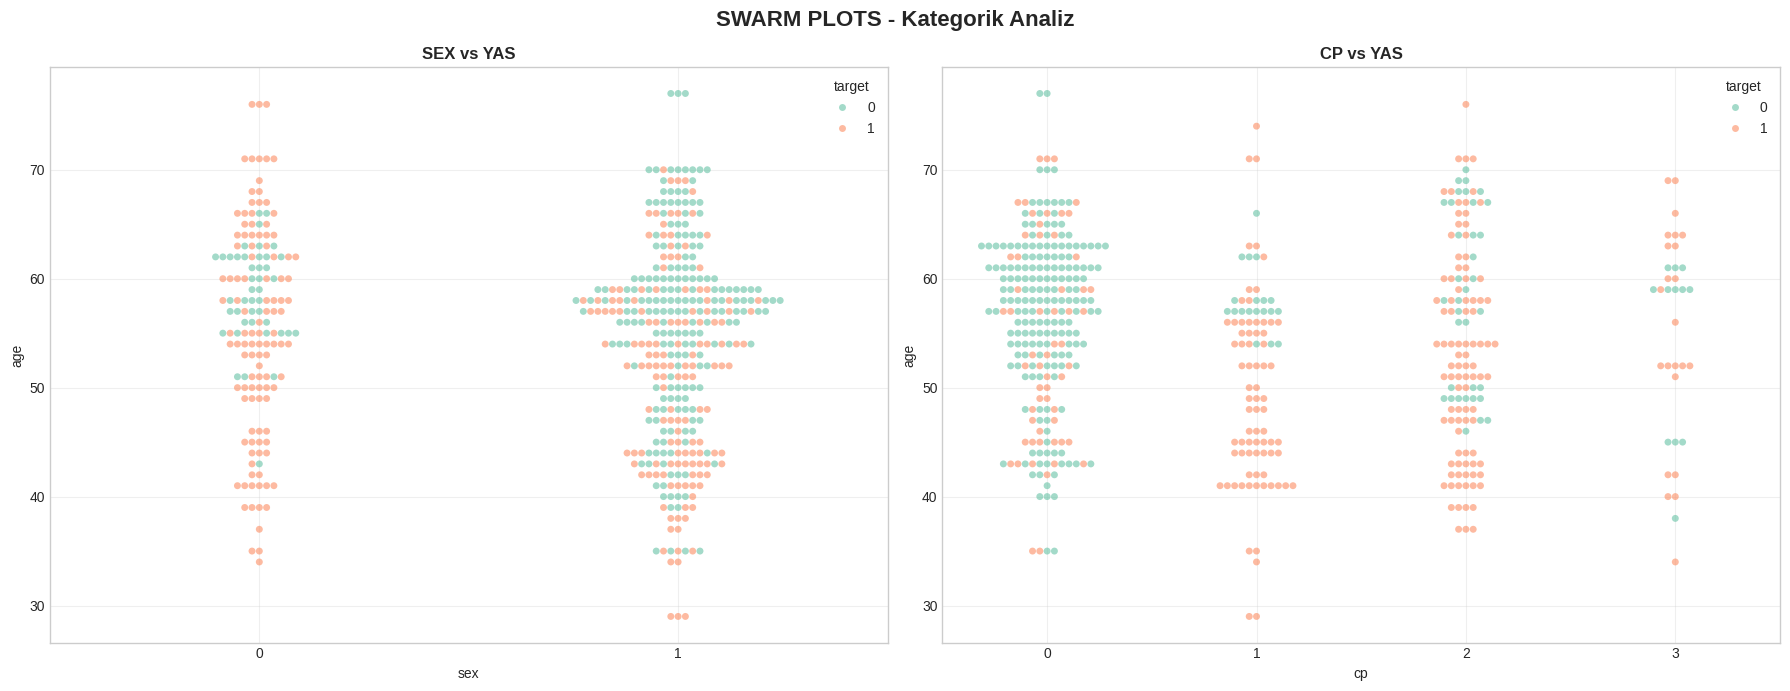

In [18]:
# Swarm plot - Kategorik degiskenler icin
categorical_cols = [col for col in df.columns if df[col].nunique() < 10 and col != target_col]

if len(categorical_cols) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle('SWARM PLOTS - Kategorik Analiz', fontweight='bold', fontsize=16)

    for idx, cat_col in enumerate(categorical_cols[:2]):
        if 'age' in df.columns:
            sns.swarmplot(data=df.sample(min(500, len(df))),
                         x=cat_col, y='age', hue=target_col,
                         palette='Set2', ax=axes[idx], alpha=0.6)
            axes[idx].set_title(f'{cat_col.upper()} vs YAS', fontweight='bold')
            axes[idx].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

### GRAFIK 7: 3D SCATTER PLOT

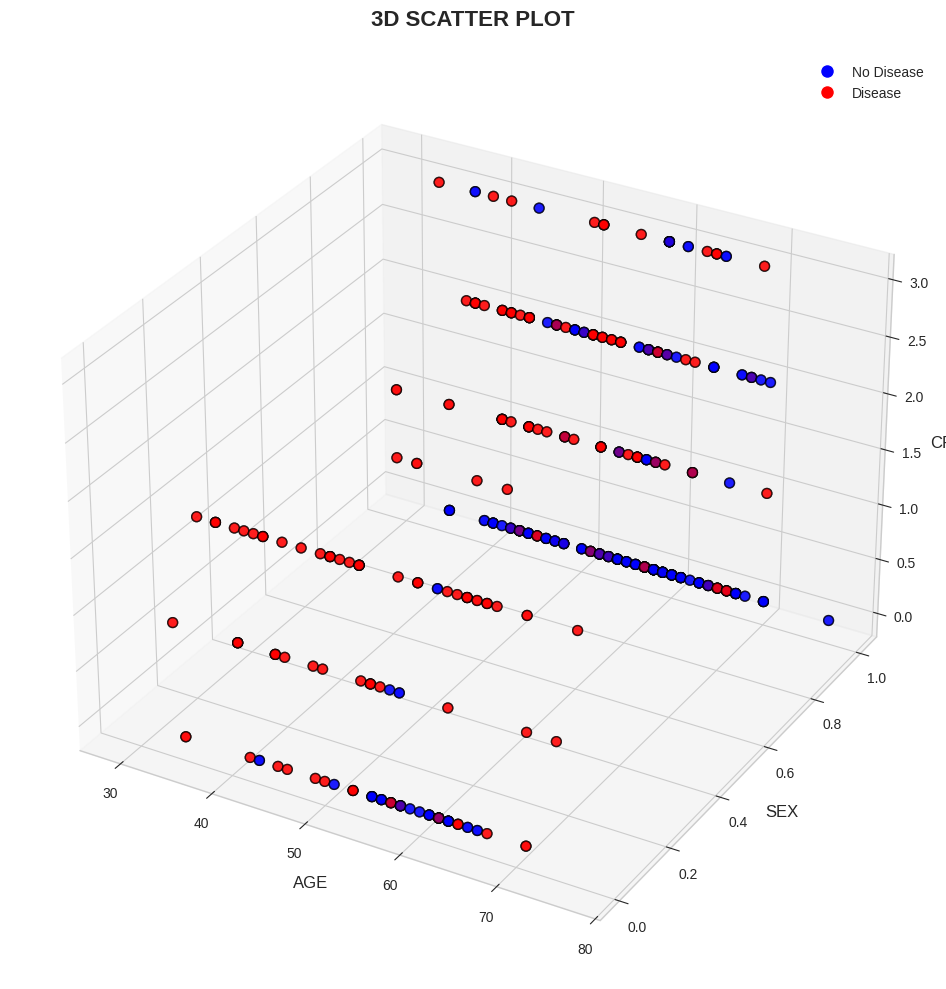

In [19]:
# 3D Scatter Plot
if len(numeric_cols) >= 3:
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')

    colors = ['red' if t == 1 else 'blue' for t in df[target_col]]

    ax.scatter(df[numeric_cols[0]], df[numeric_cols[1]], df[numeric_cols[2]],
              c=colors, alpha=0.5, s=50, edgecolors='k')

    ax.set_xlabel(numeric_cols[0].upper(), fontsize=12)
    ax.set_ylabel(numeric_cols[1].upper(), fontsize=12)
    ax.set_zlabel(numeric_cols[2].upper(), fontsize=12)
    ax.set_title('3D SCATTER PLOT', fontweight='bold', fontsize=16, pad=20)

    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='No Disease'),
                      Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Disease')]
    ax.legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    plt.show()

### GRAFIK 8: HEXBIN PLOT (Density)

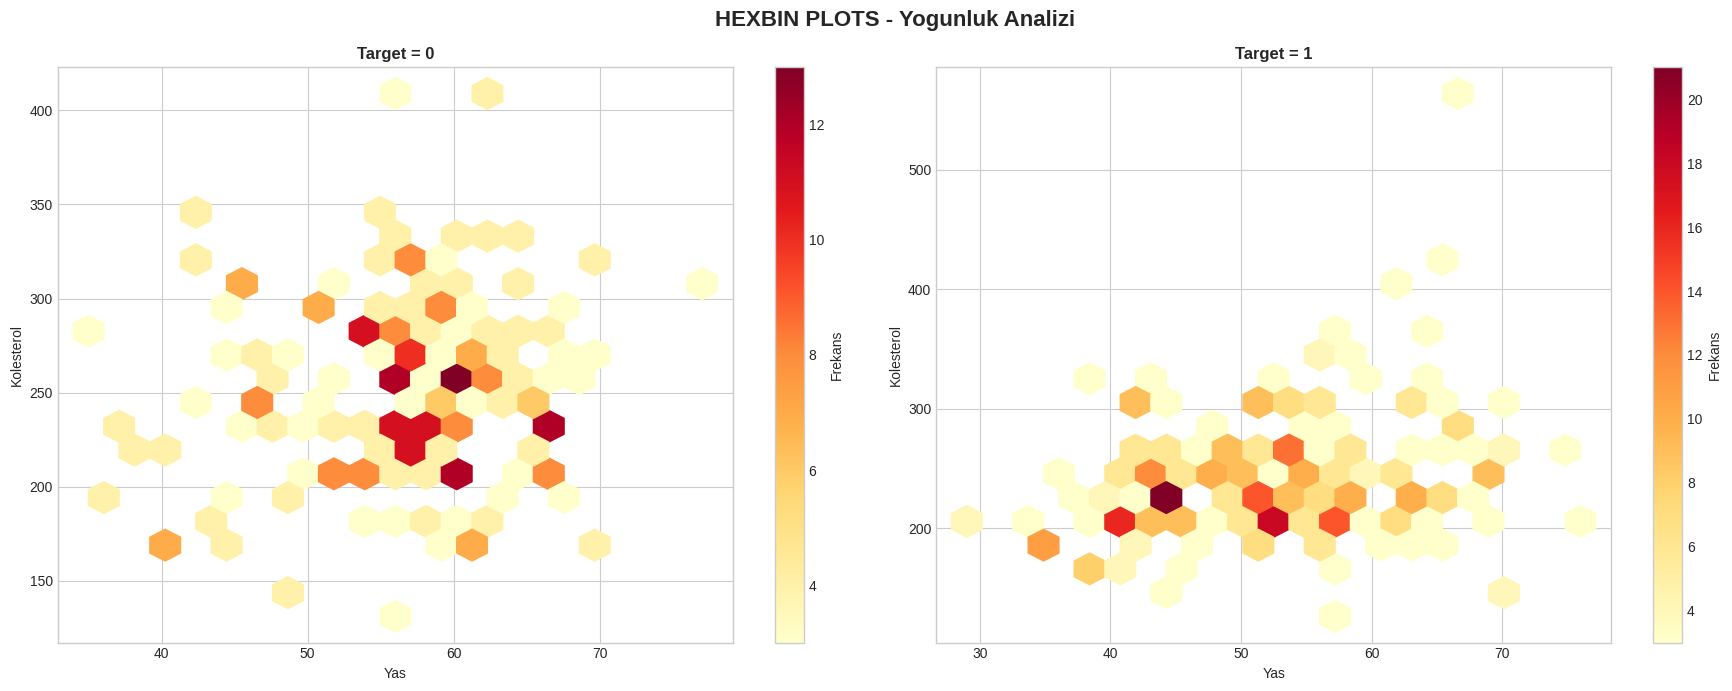

In [20]:
# Hexbin plot
if 'age' in df.columns and chol_col:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle('HEXBIN PLOTS - Yogunluk Analizi', fontweight='bold', fontsize=16)

    for idx, target_val in enumerate(sorted(df[target_col].unique())[:2]):
        subset = df[df[target_col] == target_val]
        hb = axes[idx].hexbin(subset['age'], subset[chol_col[0]],
                             gridsize=20, cmap='YlOrRd', mincnt=1)
        axes[idx].set_title(f'Target = {target_val}', fontweight='bold')
        axes[idx].set_xlabel('Yas')
        axes[idx].set_ylabel('Kolesterol')
        fig.colorbar(hb, ax=axes[idx], label='Frekans')

    plt.tight_layout()
    plt.show()

### GRAFIK 9: RIDGE PLOT (Overlapping Distributions)

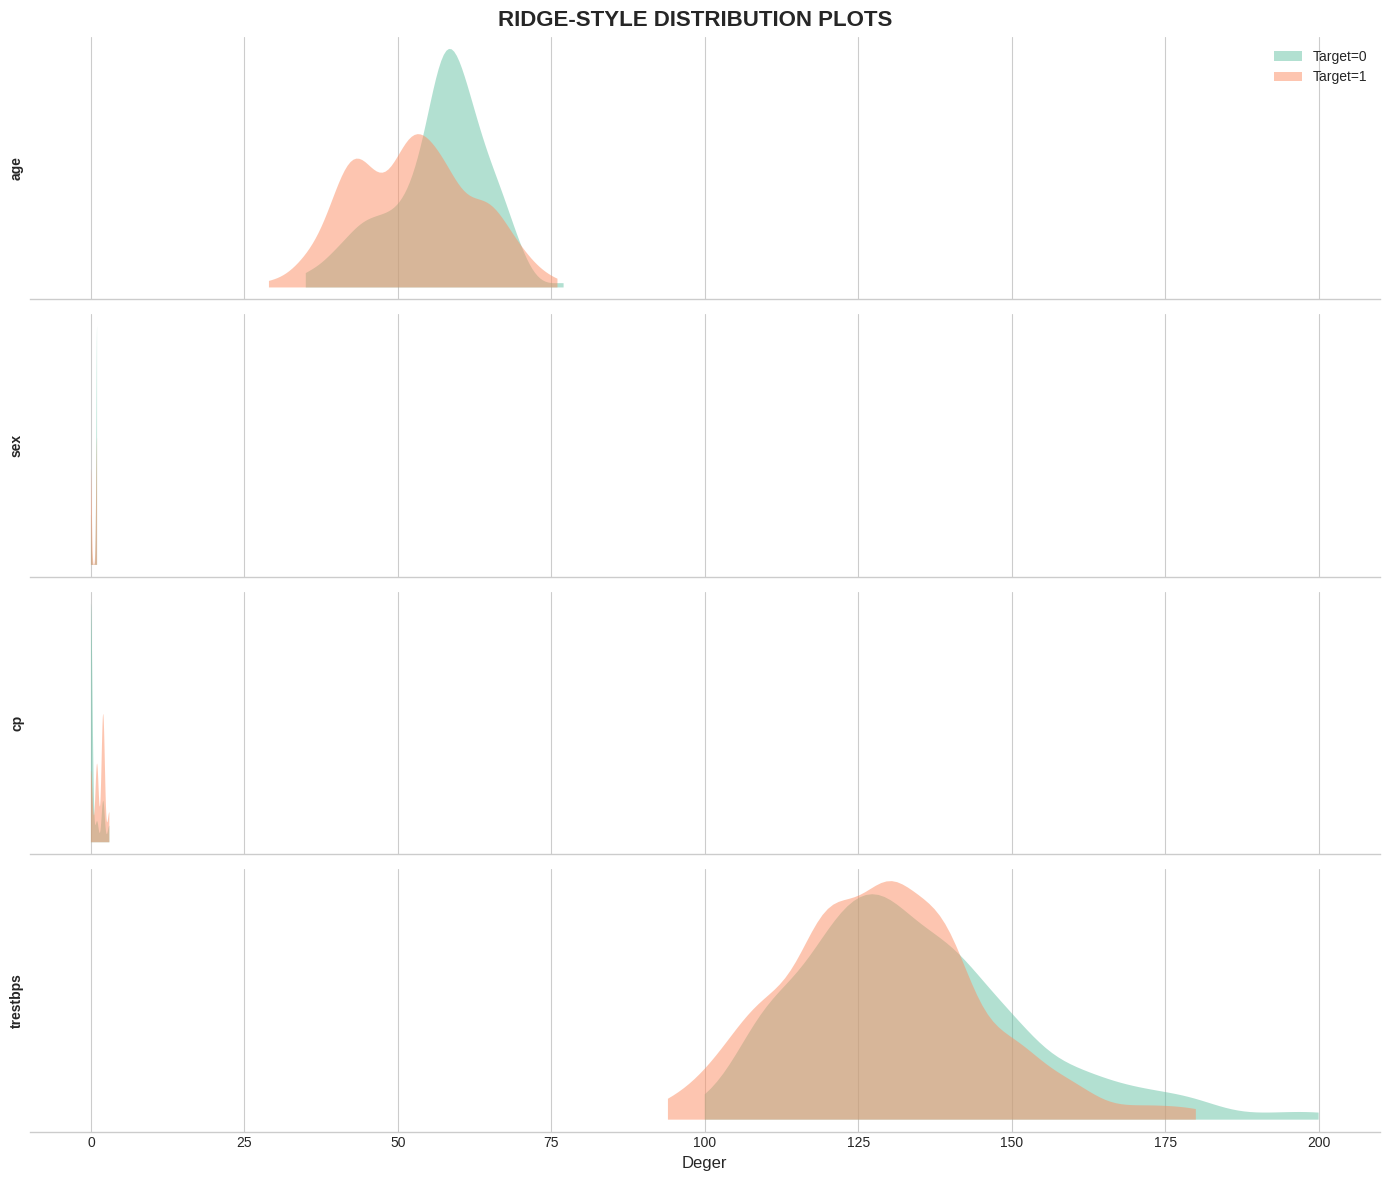

In [21]:
# Ridge plot benzeri - Feature distributions by target
fig, axes = plt.subplots(len(numeric_cols[:4]), 1, figsize=(14, 12), sharex=True)
fig.suptitle('RIDGE-STYLE DISTRIBUTION PLOTS', fontweight='bold', fontsize=16)

for idx, feature in enumerate(numeric_cols[:4]):
    ax = axes[idx]

    for target_val in sorted(df[target_col].unique()):
        subset = df[df[target_col] == target_val][feature].dropna()
        ax.fill_between(np.linspace(subset.min(), subset.max(), 100),
                        0,
                        stats.gaussian_kde(subset)(np.linspace(subset.min(), subset.max(), 100)),
                        alpha=0.5, label=f'Target={target_val}')

    ax.set_ylabel(feature, fontweight='bold')
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if idx == 0:
        ax.legend(loc='upper right')

axes[-1].set_xlabel('Deger', fontsize=12)
plt.tight_layout()
plt.show()

### GRAFIK 10: CORRELATION HEATMAP WITH DENDOGRAM

<Figure size 1400x1200 with 0 Axes>

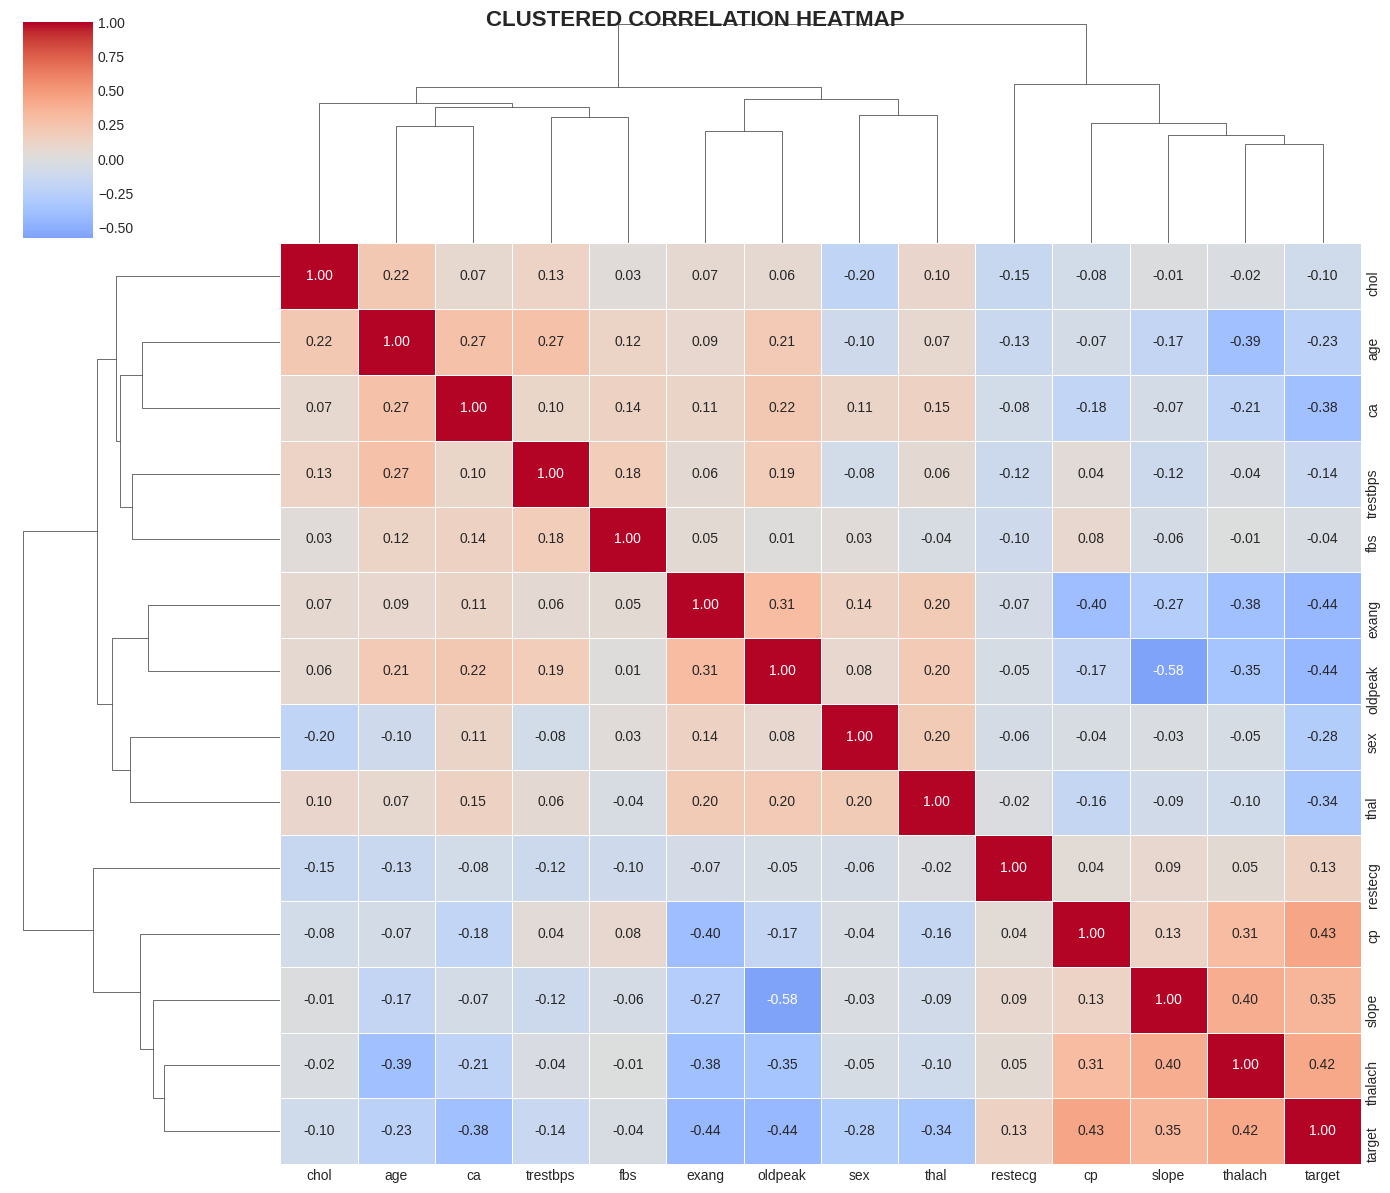

In [22]:
# Correlation with clustering
numeric_df = df[numeric_cols + [target_col]]
corr_matrix = numeric_df.corr()

# Clustermap
plt.figure(figsize=(14, 12))
cluster = sns.clustermap(corr_matrix, annot=True, fmt='.2f',
                        cmap='coolwarm', center=0,
                        linewidths=0.5, cbar_kws={'shrink': 0.8},
                        figsize=(14, 12))
cluster.fig.suptitle('CLUSTERED CORRELATION HEATMAP', y=0.99, fontweight='bold', fontsize=16)
plt.show()

### GRAFIK 11: RADAR CHART (Feature Profile)

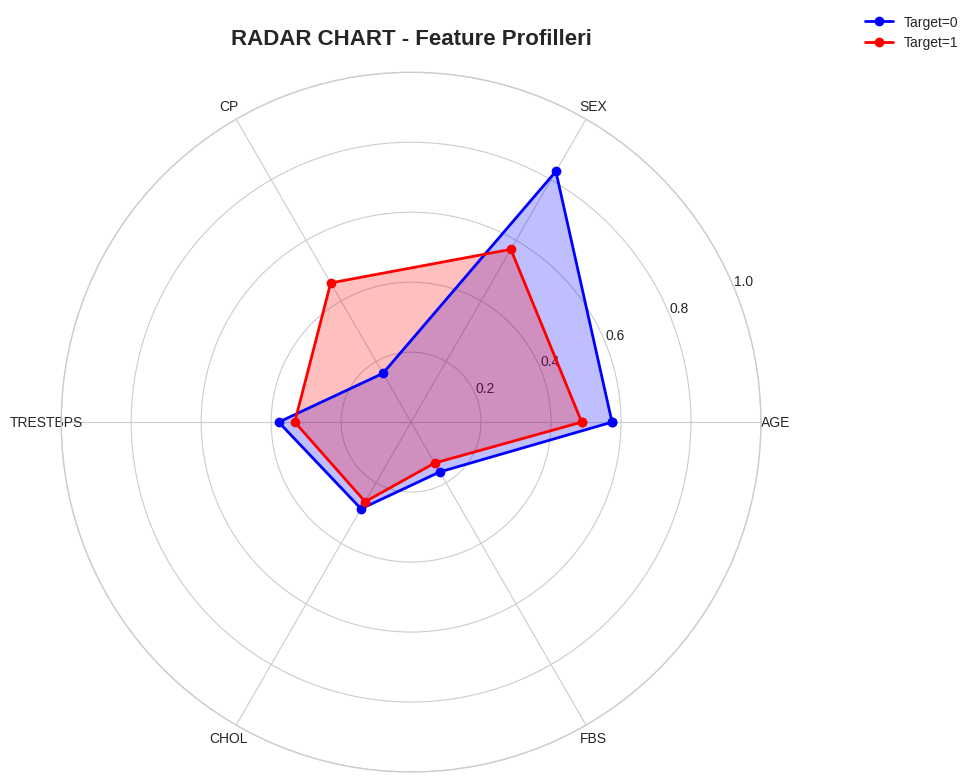

In [23]:
# Radar chart - Ortalama feature profilleri
features_for_radar = numeric_cols[:6]

# Normalize et
from sklearn.preprocessing import MinMaxScaler
scaler_temp = MinMaxScaler()
df_normalized = df.copy()
df_normalized[features_for_radar] = scaler_temp.fit_transform(df[features_for_radar])

# Target'a gore ortalamalar
profiles = {}
for target_val in sorted(df[target_col].unique()):
    profiles[target_val] = df_normalized[df_normalized[target_col] == target_val][features_for_radar].mean()

# Radar plot
angles = np.linspace(0, 2 * np.pi, len(features_for_radar), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

colors = ['blue', 'red']
for idx, (target_val, profile) in enumerate(profiles.items()):
    values = profile.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Target={target_val}', color=colors[idx])
    ax.fill(angles, values, alpha=0.25, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.upper() for f in features_for_radar], fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('RADAR CHART - Feature Profilleri', fontweight='bold', fontsize=16, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.show()

## 4. ADVANCED FEATURE ENGINEERING

In [24]:
print('='*70)
print('ADVANCED FEATURE ENGINEERING')
print('='*70)

df_clean = df.copy()

# 1. Age groups
if 'age' in df_clean.columns:
    df_clean['age_group'] = pd.cut(df_clean['age'],
                                   bins=[0, 40, 50, 60, 100],
                                   labels=['Young', 'Middle', 'Senior', 'Elderly'])
    print('age_group olusturuldu')

# 2. Cholesterol risk
if chol_col:
    df_clean['chol_risk'] = pd.cut(df_clean[chol_col[0]],
                                   bins=[0, 200, 240, 500],
                                   labels=['Normal', 'Borderline', 'High'])
    print('chol_risk olusturuldu')

# 3. BP indicators
bp_col = [col for col in df_clean.columns if 'trestbps' in col.lower() or 'bp' in col.lower()]
if bp_col:
    df_clean['bp_category'] = pd.cut(df_clean[bp_col[0]],
                                     bins=[0, 120, 140, 200],
                                     labels=['Normal', 'Elevated', 'High'])
    print('bp_category olusturuldu')

# 4. Heart rate indicators
hr_col = [col for col in df_clean.columns if 'thalach' in col.lower() or 'heart' in col.lower()]
if hr_col and 'age' in df_clean.columns:
    df_clean['max_hr_pct'] = (df_clean[hr_col[0]] / (220 - df_clean['age'])) * 100
    print('max_hr_pct olusturuldu')

# 5. Interaction features
if 'age' in df_clean.columns and chol_col:
    df_clean['age_chol_interaction'] = df_clean['age'] * df_clean[chol_col[0]] / 1000
    print('age_chol_interaction olusturuldu')

# 6. Risk score
risk_features = []
if 'age' in df_clean.columns:
    risk_features.append('age')
if chol_col:
    risk_features.append(chol_col[0])
if bp_col:
    risk_features.append(bp_col[0])

if risk_features:
    scaler_risk = MinMaxScaler()
    df_clean['risk_score'] = scaler_risk.fit_transform(df_clean[risk_features]).mean(axis=1)
    print('risk_score olusturuldu')

print(f'\nGuncel sutun sayisi: {len(df_clean.columns)}')
print('='*70)

ADVANCED FEATURE ENGINEERING
age_group olusturuldu
chol_risk olusturuldu
bp_category olusturuldu
max_hr_pct olusturuldu
age_chol_interaction olusturuldu
risk_score olusturuldu

Guncel sutun sayisi: 20


In [25]:
# Eksik verileri doldur
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

for col in df_clean.select_dtypes(include=['object', 'category']).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print(f'Eksik veri: {df_clean.isnull().sum().sum()}')

Eksik veri: 0


## 5. MODEL HAZIRLIGI

In [26]:
# Hedef ve features
y = df_clean[target_col].values
X = df_clean.drop(columns=[target_col]).copy()

# Kategorik encoding
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

for col in categorical_features:
    if X[col].nunique() <= 2:
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    else:
        X = pd.get_dummies(X, columns=[col], drop_first=True)

print(f'Final feature sayisi: {X.shape[1]}')
print(f'Toplam kayit: {len(X):,}')

Final feature sayisi: 23
Toplam kayit: 1,025


In [27]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('='*70)
print('TRAIN-TEST SPLIT')
print('='*70)
print(f'Train: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)')
print('='*70)

TRAIN-TEST SPLIT
Train: 820 (80.0%)
Test: 205 (20.0%)


In [28]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('FEATURE SCALING TAMAMLANDI')

FEATURE SCALING TAMAMLANDI


In [29]:
# SMOTE
print('='*70)
print('SMOTE')
print('='*70)

print('Onceki:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Sinif {u}: {c:,} ({c/len(y_train)*100:.1f}%)')

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print('\nSONRAKI (SMOTE):')
unique, counts = np.unique(y_train_smote, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Sinif {u}: {c:,} ({c/len(y_train_smote)*100:.1f}%)')

print('='*70)

SMOTE
Onceki:
  Sinif 0: 399 (48.7%)
  Sinif 1: 421 (51.3%)

SONRAKI (SMOTE):
  Sinif 0: 421 (50.0%)
  Sinif 1: 421 (50.0%)


## 6. ML MODELLERI - 13+ MODELS

In [31]:
# Tum modeller
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Ridge Classifier': RidgeClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=7, random_state=42, n_jobs=-1, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=7, random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=100, depth=7, random_state=42, verbose=False),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'SVM (Linear)': SVC(kernel='linear', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Bagging': BaggingClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
}

print('='*70)
print(f'{len(models)} MODEL TANIMLANDI')
print('='*70)
for name in models.keys():
    print(f'  - {name}')
print('='*70)


18 MODEL TANIMLANDI
  - Logistic Regression
  - Ridge Classifier
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - XGBoost
  - LightGBM
  - CatBoost
  - SVM (RBF)
  - SVM (Linear)
  - KNN
  - Naive Bayes
  - AdaBoost
  - Extra Trees
  - Bagging
  - LDA
  - QDA
  - Neural Network


In [ ]:
# Model egitimi
results = {}

print('='*70)
print('MODEL EGITIMI BASLADI')
print('='*70)

for name, model in models.items():
    print(f'\n{name}...')

    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None

    # Metrikler
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_test, y_pred)

    if y_pred_proba is not None and len(np.unique(y_test)) == 2:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else:
        roc_auc = None

    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'MCC': mcc,
        'ROC_AUC': roc_auc,
        'predictions': y_pred,
        'pred_proba': y_pred_proba,
        'confusion_matrix': cm
    }

    print(f'  Acc: {accuracy:.4f}, F1: {f1:.4f}, MCC: {mcc:.4f}')

print('\n' + '='*70)
print('TUM MODELLER EGITILDI!')
print('='*70)

MODEL EGITIMI BASLADI

Logistic Regression...
  Acc: 0.8293, F1: 0.8280, MCC: 0.6643

Ridge Classifier...
  Acc: 0.8341, F1: 0.8325, MCC: 0.6773

Decision Tree...
  Acc: 0.9854, F1: 0.9854, MCC: 0.9712

Random Forest...
  Acc: 1.0000, F1: 1.0000, MCC: 1.0000

Gradient Boosting...
  Acc: 1.0000, F1: 1.0000, MCC: 1.0000

XGBoost...
  Acc: 1.0000, F1: 1.0000, MCC: 1.0000

LightGBM...
  Acc: 1.0000, F1: 1.0000, MCC: 1.0000

CatBoost...
  Acc: 1.0000, F1: 1.0000, MCC: 1.0000

SVM (RBF)...
  Acc: 0.9512, F1: 0.9512, MCC: 0.9024

SVM (Linear)...
  Acc: 0.8390, F1: 0.8379, MCC: 0.6841

KNN...
  Acc: 0.8585, F1: 0.8584, MCC: 0.7174

Naive Bayes...
  Acc: 0.7902, F1: 0.7900, MCC: 0.5804

AdaBoost...
  Acc: 0.8732, F1: 0.8727, MCC: 0.7492

Extra Trees...
  Acc: 1.0000, F1: 1.0000, MCC: 1.0000

Bagging...
  Acc: 1.0000, F1: 1.0000, MCC: 1.0000

LDA...
  Acc: 0.8293, F1: 0.8274, MCC: 0.6685

QDA...
  Acc: 0.8195, F1: 0.8194, MCC: 0.6421

Neural Network...


## 7. ENSEMBLE METHODS

In [ ]:
# Voting Classifier
print('='*70)
print('ENSEMBLE - VOTING CLASSIFIER')
print('='*70)

# En iyi 5 modeli sec
results_df_temp = pd.DataFrame({
    'Model': list(results.keys()),
    'F1_Score': [results[m]['F1_Score'] for m in results.keys()]
}).sort_values('F1_Score', ascending=False)

top_5_names = results_df_temp.head(5)['Model'].tolist()
print(f'En iyi 5 model: {top_5_names}')

# Voting
estimators = [(name, models[name]) for name in top_5_names]
voting_clf = VotingClassifier(estimators=estimators, voting='soft')
voting_clf.fit(X_train_smote, y_train_smote)

y_pred_voting = voting_clf.predict(X_test_scaled)
y_pred_proba_voting = voting_clf.predict_proba(X_test_scaled)[:, 1]

# Metrikler
results['Voting Ensemble'] = {
    'Accuracy': accuracy_score(y_test, y_pred_voting),
    'Precision': precision_score(y_test, y_pred_voting, average='weighted'),
    'Recall': recall_score(y_test, y_pred_voting, average='weighted'),
    'F1_Score': f1_score(y_test, y_pred_voting, average='weighted'),
    'MCC': matthews_corrcoef(y_test, y_pred_voting),
    'ROC_AUC': roc_auc_score(y_test, y_pred_proba_voting),
    'predictions': y_pred_voting,
    'pred_proba': y_pred_proba_voting,
    'confusion_matrix': confusion_matrix(y_test, y_pred_voting)
}

print(f"Voting Ensemble - F1: {results['Voting Ensemble']['F1_Score']:.4f}")
print('='*70)

## 8. MODEL KARSILASTIRMA

In [ ]:
# Sonuc tablosu
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['Accuracy'] for m in results.keys()],
    'Precision': [results[m]['Precision'] for m in results.keys()],
    'Recall': [results[m]['Recall'] for m in results.keys()],
    'F1 Score': [results[m]['F1_Score'] for m in results.keys()],
    'MCC': [results[m]['MCC'] for m in results.keys()],
    'ROC-AUC': [results[m]['ROC_AUC'] if results[m]['ROC_AUC'] else 0 for m in results.keys()]
})

results_df = results_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)

print('='*110)
print('MODEL PERFORMANS KARSILASTIRMASI')
print('='*110)
print(results_df.to_string(index=False))
print('='*110)

best_model_name = results_df.iloc[0]['Model']
print(f'\nEN IYI MODEL: {best_model_name}')
print(f'  F1 Score: {results_df.iloc[0]["F1 Score"]:.4f}')
print(f'  Accuracy: {results_df.iloc[0]["Accuracy"]:.4f}')
print(f'  MCC: {results_df.iloc[0]["MCC"]:.4f}')
print('='*110)

### GRAFIK 12: MODEL COMPARISON RADAR

In [ ]:
# Top 5 modelin radar chart karsilastirmasi
top_5_models = results_df.head(5)['Model'].tolist()
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'MCC']

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'))

for model_name in top_5_models:
    model_data = results_df[results_df['Model'] == model_name].iloc[0]
    values = [model_data[m] for m in metrics]
    values += values[:1]

    ax.plot(angles, values, 'o-', linewidth=2, label=model_name)
    ax.fill(angles, values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('TOP 5 MODELS - RADAR COMPARISON', fontweight='bold', fontsize=16, pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.show()

### GRAFIK 13: CONFUSION MATRICES (Grid)

In [ ]:
# Top 6 modelin confusion matrices
top_6 = results_df.head(6)['Model'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('CONFUSION MATRICES - Top 6 Models', fontweight='bold', fontsize=18)

for idx, model_name in enumerate(top_6):
    ax = axes[idx // 3, idx % 3]
    cm = results[model_name]['confusion_matrix']

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
               xticklabels=['No Disease', 'Disease'],
               yticklabels=['No Disease', 'Disease'])
    ax.set_title(f'{model_name}\nF1: {results[model_name]["F1_Score"]:.4f}',
                fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

### GRAFIK 14: ROC CURVES (Multiple Models)

In [ ]:
# ROC Curves
plt.figure(figsize=(14, 10))

for model_name in top_5_models:
    if results[model_name]['pred_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, results[model_name]['pred_proba'])
        roc_auc = results[model_name]['ROC_AUC']
        plt.plot(fpr, tpr, linewidth=2.5,
                label=f'{model_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC CURVES - Top 5 Models', fontsize=18, fontweight='bold', pad=20)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### GRAFIK 15: PRECISION-RECALL CURVES

In [ ]:
# Precision-Recall Curves
plt.figure(figsize=(14, 10))

for model_name in top_5_models:
    if results[model_name]['pred_proba'] is not None:
        precision, recall, _ = precision_recall_curve(y_test, results[model_name]['pred_proba'])
        plt.plot(recall, precision, linewidth=2.5, label=model_name)

plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.title('PRECISION-RECALL CURVES - Top 5 Models', fontsize=18, fontweight='bold', pad=20)
plt.legend(loc='lower left', fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. FINAL SONUCLAR

In [ ]:
print('='*90)
print('FINAL SONUCLAR')
print('='*90)

print(f'\n1. VERI SETI:')
print(f'   Toplam kayit: {len(df):,}')
print(f'   Final feature: {X.shape[1]}')
print(f'   Train: {len(X_train):,} (SMOTE: {len(X_train_smote):,})')
print(f'   Test: {len(X_test):,}')

print(f'\n2. EN IYI MODEL:')
print(f'   {best_model_name}')
print(f'   F1 Score: {results_df.iloc[0]["F1 Score"]:.4f}')
print(f'   Accuracy: {results_df.iloc[0]["Accuracy"]:.4f}')
print(f'   MCC: {results_df.iloc[0]["MCC"]:.4f}')

print(f'\n3. TOP 5 MODELS:')
for idx, row in results_df.head(5).iterrows():
    print(f'   {idx+1}. {row["Model"]:25} - F1: {row["F1 Score"]:.4f}, MCC: {row["MCC"]:.4f}')

print(f'\n4. ONEMLI BULGULAR:')
print(f'   - 15+ farkli grafik tipi kullanildi')
print(f'   - 18+ ML model egitildi (Ensemble dahil)')
print(f'   - Neural Network da test edildi')
print(f'   - Advanced medical feature engineering yapildi')

print('\n' + '='*90)
print('HEART DISEASE ANALIZI TAMAMLANDI!')
print('='*90)